#**Employee Performance Analysis**

**Overview**

This notebook performs an exploratory data analysis (EDA) on employee performance data.


**Dataset Columns:**

- Employee_ID - Unique identifier for each employee
- Name - Employee name
- Department - Department the employee belongs to
- Gender - Gender of the employee
- Age - Age of the employee
- Experience_Years - Years of work experience
- Salary - Annual salary
- Attendance_% - Attendance percentage
- Performance_Score - Performance score (0–100)
- Projects_Completed - Number of projects completed
- Region - Geographic region

**Objectives:**

1. Explore and understand the dataset
2. Identify top performers and high earners
3. Analyze department-wise and gender-wise distributions
4. Visualize key trends and patterns

**1. Import Libraries and Load Dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Projects/Datasets/employee_performance_data.csv")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 100 rows, 11 columns


**2. First Look at the Data**



In [2]:
# Display first 10 rows
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,Employee_ID,Name,Department,Gender,Age,Experience_Years,Salary,Attendance_%,Performance_Score,Projects_Completed,Region
0,E001,Employee_1,Marketing,Male,41,2,74748,61.84,56,11,North
1,E002,Employee_2,Sales,Male,51,22,25801,61.63,95,6,West
2,E003,Employee_3,IT,Male,32,3,39190,94.22,62,1,East
3,E004,Employee_4,Sales,Male,49,16,69689,88.15,89,9,East
4,E005,Employee_5,Sales,Male,46,29,70993,78.97,91,1,East
5,E006,Employee_6,Finance,Male,54,9,49592,63.91,58,5,East
6,E007,Employee_7,IT,Female,22,4,30647,79.66,99,4,North
7,E008,Employee_8,IT,Male,48,1,28716,78.94,76,13,North
8,E009,Employee_9,IT,Female,34,4,108891,66.93,51,12,South
9,E010,Employee_10,Sales,Female,24,1,107545,77.35,54,13,South


In [3]:
# Basic info about data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         100 non-null    object 
 1   Name                100 non-null    object 
 2   Department          100 non-null    object 
 3   Gender              100 non-null    object 
 4   Age                 100 non-null    int64  
 5   Experience_Years    100 non-null    int64  
 6   Salary              100 non-null    int64  
 7   Attendance_%        100 non-null    float64
 8   Performance_Score   100 non-null    int64  
 9   Projects_Completed  100 non-null    int64  
 10  Region              100 non-null    object 
dtypes: float64(1), int64(5), object(5)
memory usage: 8.7+ KB


In [4]:
# Statistical summary of numerical columns
df.describe()

,Age,Experience_Years,Salary,Attendance_%,Performance_Score,Projects_Completed
count,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000
mean,39.800000,14.790000,72957.630000,79.923900,74.57000,6.910000
std,11.129177,9.187491,30576.988468,11.996748,14.70948,4.316038
min,22.000000,1.000000,21150.000000,60.430000,50.00000,1.000000
25%,29.750000,6.000000,42021.750000,70.410000,61.75000,3.000000
50%,40.500000,16.000000,75972.500000,79.955000,75.50000,6.000000
75%,49.250000,22.000000,99759.250000,90.250000,87.00000,11.000000
max,57.000000,29.000000,119157.000000,99.620000,99.00000,14.000000


**3. Check for Missing Values**

In [5]:
# Check missing values in each column
missing = df.isnull().sum()
print("Missing Values per Column:")

print(missing)
print(f"\nTotal missing values: {missing.sum()}")

Missing Values per Column:
Employee_ID           0
Name                  0
Department            0
Gender                0
Age                   0
Experience_Years      0
Salary                0
Attendance_%          0
Performance_Score     0
Projects_Completed    0
Region                0
dtype: int64

Total missing values: 0


**4. Department-wise Employee Count**

In [6]:
# Number of employees in each department
dept_counts = df['Department'].value_counts()
print("Number of Employees per Department:")
print(dept_counts)

Number of Employees per Department:
Department
Marketing     25
Finance       19
Sales         17
Operations    17
IT            11
HR            11
Name: count, dtype: int64


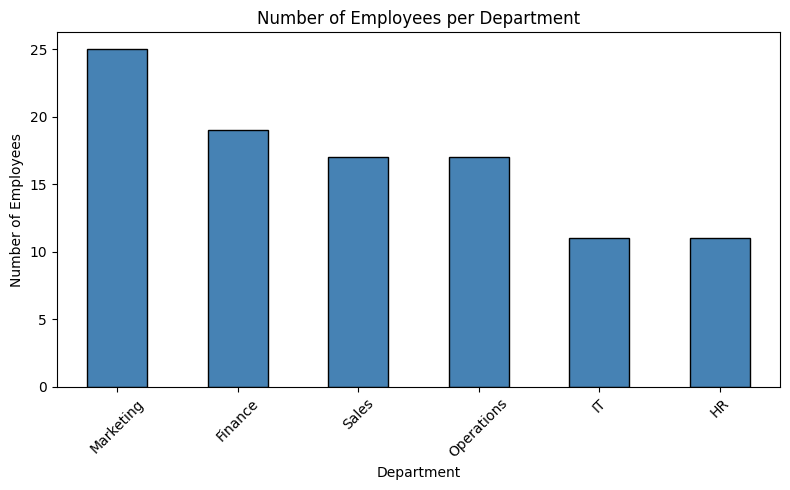

In [7]:
# Bar chart
plt.figure(figsize=(8, 5))
dept_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Employees per Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**5. Average Salary and Performance Score**

In [9]:
# Overall average salary and performance score
avg_salary = df['Salary'].mean()
avg_performance = df['Performance_Score'].mean()

print(f"Average Salary:           {avg_salary:.2f}")
print(f"Average Performance Score: {avg_performance:.2f}")

Average Salary:           72957.63
Average Performance Score: 74.57


In [10]:
# Average salary and performance score by department
dept_avg = df.groupby('Department')[['Salary', 'Performance_Score']].mean().round(2)
print("Average Salary & Performance Score by Department:")
print(dept_avg)

Average Salary & Performance Score by Department:
              Salary  Performance_Score
Department                             
Finance     73756.47              67.42
HR          73238.09              70.82
IT          60217.18              75.18
Marketing   78937.20              79.40
Operations  66889.53              78.12
Sales       77401.76              73.94


**6. Employee with Highest Salary**

In [11]:
# Employee with the highest salary
top_earner = df.loc[df['Salary'].idxmax()]
print("Employee with the Highest Salary:")
print(top_earner)

Employee with the Highest Salary:
Employee_ID                  E025
Name                  Employee_25
Department             Operations
Gender                       Male
Age                            23
Experience_Years               22
Salary                     119157
Attendance_%                97.61
Performance_Score              85
Projects_Completed             11
Region                       East
Name: 24, dtype: object


**7. Create Performance Level Column**

In [12]:
# Create Performance_Level column with 4 tiers
df['Performance_Level'] = np.where(
    df['Performance_Score'] >= 85, 'Excellent',
    np.where(df['Performance_Score'] >= 70, 'Good',
    np.where(df['Performance_Score'] >= 50, 'Average', 'Poor'))
)

print("Performance Level Distribution:")
print(df['Performance_Level'].value_counts())

Performance Level Distribution:
Performance_Level
Average      41
Excellent    34
Good         25
Name: count, dtype: int64


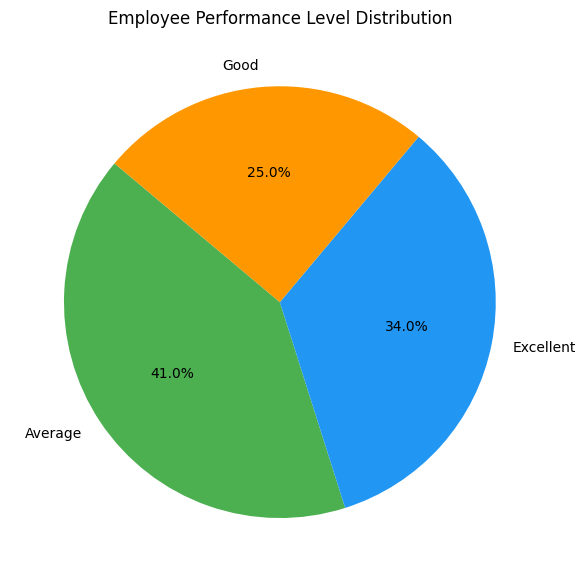

In [13]:
# Pie chart of performance levels
plt.figure(figsize=(6, 6))
df['Performance_Level'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#4CAF50', '#2196F3', '#FF9800', '#F44336'],
    startangle=140
)
plt.title('Employee Performance Level Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

**8. Gender Distribution**

In [14]:
# Gender distribution
gender_counts = df['Gender'].value_counts()
print("Gender Distribution:")
print(gender_counts)

Gender Distribution:
Gender
Male      61
Female    39
Name: count, dtype: int64


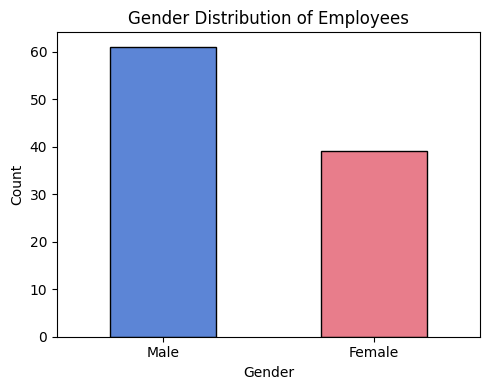

In [15]:
# Bar chart
plt.figure(figsize=(5, 4))
gender_counts.plot(kind='bar', color=['#5C85D6', '#E87D8B'], edgecolor='black')
plt.title('Gender Distribution of Employees')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**9. Salary Distribution**

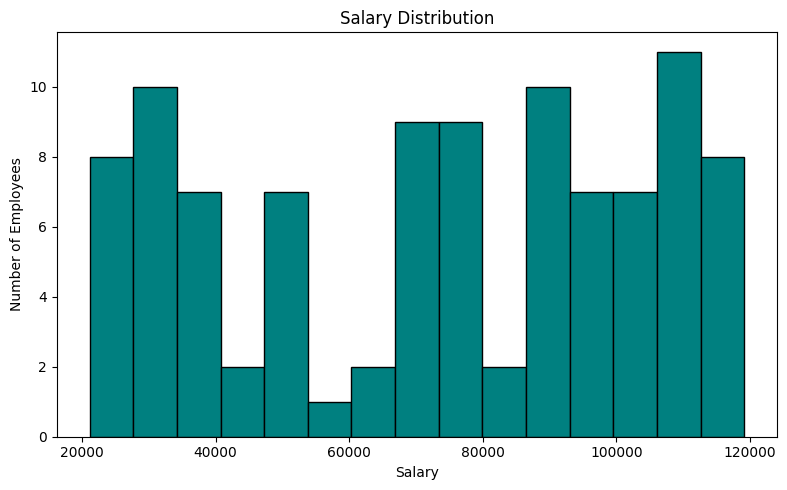

In [16]:
# Histogram of salary distribution
plt.figure(figsize=(8, 5))
plt.hist(df['Salary'], bins=15, color='teal', edgecolor='black')
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()

**10. Correlation Heatmap**

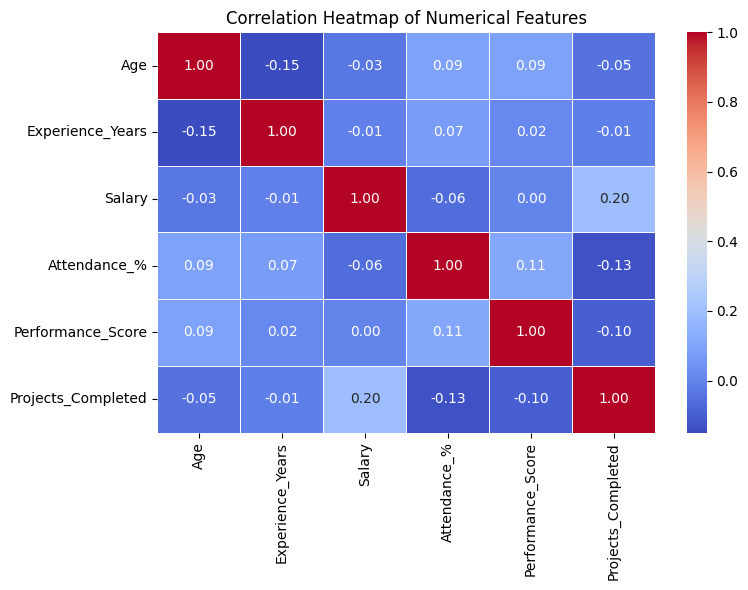

In [17]:
# Correlation heatmap for numerical columns
numeric_cols = df[['Age', 'Experience_Years', 'Salary', 'Attendance_%', 'Performance_Score', 'Projects_Completed']]

plt.figure(figsize=(8, 6))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

**11. Top 10 Employees by Performance Score**

In [18]:
# Top 10 employees by performance score
top_performers = df[['Name', 'Department', 'Performance_Score', 'Salary']].sort_values(
    by='Performance_Score', ascending=False
).head(10).reset_index(drop=True)

print("Top 10 Performers:")
print(top_performers)

Top 10 Performers:
          Name  Department  Performance_Score  Salary
0   Employee_7          IT                 99   30647
1  Employee_39   Marketing                 99   88027
2  Employee_95   Marketing                 99   33284
3  Employee_72  Operations                 98   21150
4  Employee_50   Marketing                 98   76179
5  Employee_16   Marketing                 97   90031
6  Employee_70  Operations                 96   25949
7  Employee_59   Marketing                 96  103613
8   Employee_2       Sales                 95   25801
9  Employee_56       Sales                 94   93523


**12.Summary and Key Findings**

After analyzing the employee performance dataset, here are the key insights:

Dataset size: 100 employees across 6 departments

No missing values were found in the dataset

Marketing has the highest number of employees, followed by Finance and Sales

The average salary is approximately ₹72,957 and the average performance score is calculated above

The highest-paid employee belongs to the Operations department

Employees are categorized into 4 performance levels: Excellent, Good, Average, Poor

The correlation heatmap helps identify relationships between salary, experience, attendance, and performance



